=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


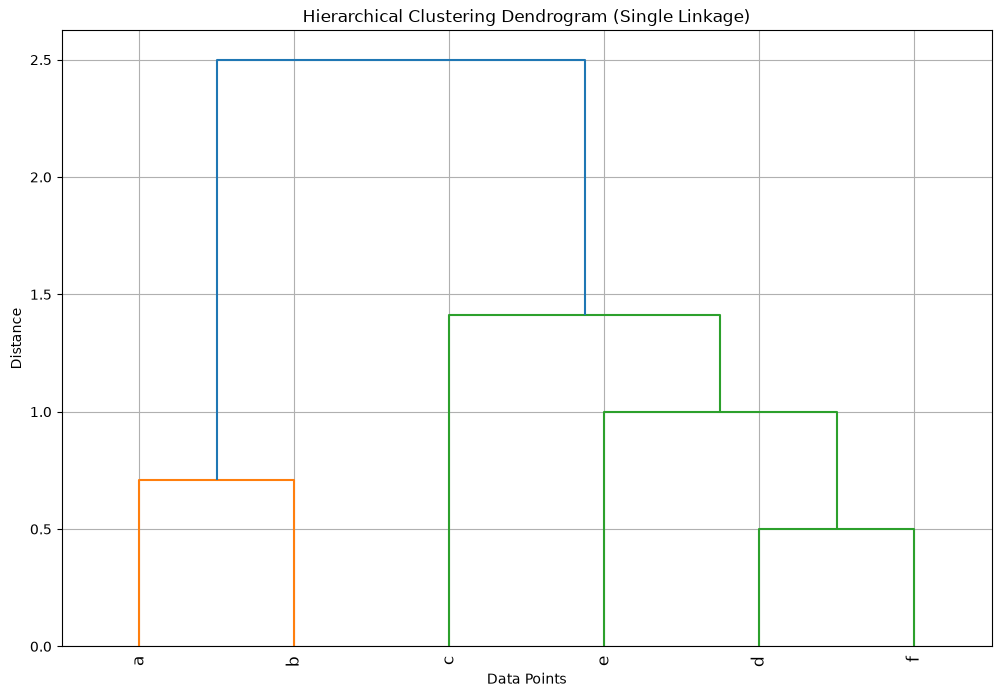

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

#1. dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

#2. hitung distance matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
columns=['a', 'b', 'c', 'd', 'e', 'f'],
index=['a', 'b', 'c', 'd', 'e', 'f'])

#3.tampilkan distance matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

#4. hierarchical clustering (single linkage)
linked = linkage(data, method='single')

#5. plot dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()


- import numpy as np dan import pandas as pd dimuat untuk menangani struktur data array dan tabel DataFrame.

- Modul linkage dan dendrogram diimpor dari scipy.cluster.hierarchy untuk memproses logika pengelompokan hierarki serta merender diagram pohonnya, sementara pdist dan squareform dari scipy.spatial.distance untuk mengkalkulasi matriks jarak spasial antar titik. 

- import matplotlib.pyplot as plt sebagai engine utama untuk menampilkan hasil visualisasi grafis ke layar.

- variabel data = np.array([...]) mendeklarasikan sebuah matriks NumPy dua dimensi yang berisi enam sampel titik koordinat. 

- baris distance_matrix = pdist(data, metric='euclidean') Baris ini dipakai buat menghitung jarak garis lurus (jarak Euclidean) dari setiap titik ke titik lainnya secara otomatis.

-  distance_df = pd.DataFrame(squareform(distance_matrix), ...)
Hasil hitungan jarak yang tadinya hanya deretan angka biasa diubah sama perintah ini jadi bentuk tabel rapi (matriks) lengkap dengan nama kolom dan barisnya.

- linked = linkage(data, method='single')
Fungsi ini jalanin rumus hierarchical clustering menggunakan cara single linkage (mencari titik yang paling dekat jaraknya) untuk mulai menggabungkan data-data yang posisinya berdekatan secara bertahap.

- plt.title(...) untuk menambah judulnya di bagian atas grafik ("Hierarchical Clustering Dendrogram...").

- dendrogram(linked, labels=[...], leaf_rotation=90) untuk menggambar diagram pohonnya atau dendrogram. Parameter labels memberi nama huruf $a-f$ di setiap batangnya, terus leaf_rotation=90 memutar tulisan hurufnya sebesar 90 derajat agar berdiri tegak dan tidak saling tabrakan.

- plt.xlabel(...), plt.ylabel(...), dan plt.grid(True) untuk menambahkan keterangan nama di garis bawah (sumbu X), garis samping (sumbu Y), dan nampilin garis-garis kotak bantuan (grid).

In [2]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head ()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


- import pandas as pd dipakai buat untuk memanggil atau mengaktifkan pustaka Pandas ke dalam program, lalu diberi nama pendek pd. 

- df = pd.read_csv("Mall_Customers.csv") berfungsi buat membaca file data berformat CSV, lalu menyimpannya ke dalam memori bernama variabel df (dataframe). 

- df.head()
Ini perintah buat menampilkan 5 baris pertama dari tabel df 

In [ ]:
x = df.iloc [:, [3,4]].values

- df adalah variabel tabel utama (DataFrame) yang berisi keseluruhan data dari file CSV.

- .iloc[:, [3,4]]
Tanda titik dua (:) di sebelah kiri koma untuk mengambil semua baris data yang ada di tabel.

- Di sebelah kanan koma, ada [3,4] di dalam tanda kurung siku. secara spesifik hanya mau mengambil kolom indeks ke-3 dan ke-4 saja, sementara kolom lain diabaikan.

- .values berfungsi untuk mengubah format data yang tadinya masih berupa tabel Pandas menjadi bentuk NumPy array. 

- x = ...
Semua hasil seleksi kolom dan perubahan format di atas kemudian disimpan ke dalam wadah variabel baru bernama x.

In [5]:
from sklearn.preprocessing import StandardScaler 

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

- from sklearn.preprocessing import StandardScaler dipakai untuk memanggil StandardScaler dari pustaka Scikit-Learn. fungsinya buat standarisasi data, yaitu mengubah angka-angka di data supaya punya rata-rata (mean) sama dengan 0 dan simpangan baku (standard deviation) sama dengan 1.

- data_scaler = StandardScaler() menyiapkan atau menginisialisasi alat standarisasinya dan menyimpannya ke dalam variabel bernama data_scaler supaya siap dipakai buat memproses data.

- scaled_data = data_scaler.fit_transform(x). Perintah fit_transform bertugas dua hal sekaligus yaitu untuk menghitung rumus rata-rata dan standar deviasi dari data x, lalu langsung mengubah atau mentransformasi seluruh nilai data x tersebut ke dalam skala baru yang sudah distandarisasi. Hasil akhirnya disimpan di variabel scaled_data.

- scaled_data.shape untuk cek dimensi atau ukuran bentuk dari data yang sudah diskalakan tadi.

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

- from scipy.cluster.hierarchy import linkage, dendrogram untuk mengimpor dua fungsi penting dari modul hirarki SciPy yaitu linkage yang bertugas menghitung proses penggabungan klaster secara bertingkat, dan dendrogram yang dipakai buat menggambar diagram pohonnya.

- scaled_data adalah data yang di masukkan sebagai bahan utama klaster..

- method="complete" adalah aturan atau metode penggabungan klaster yang dipakai adalah complete linkage. Artinya, jarak antar dua klaster dihitung berdasarkan jarak terjauh antara titik di klaster pertama dan titik di klaster kedua.

- metric="euclidean" yaitu rumus ukur jarak yang dipakai antar titik datanya adalah jarak garis lurus.


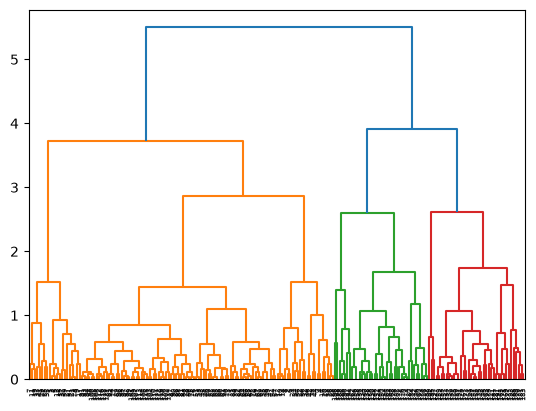

In [7]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

- import matplotlib.pyplot as plt untuk mengaktifkan kembali pustaka Matplotlib (khususnya modul pyplot) yang bertugas sebagai engine utama untuk membuat grafik. 

- dendrogram(clustering) adalah perintah utama untuk menggambar diagram pohon (dendrogram). Fungsi ini mengambil hasil ringkasan penggabungan klaster dari variabel clustering yang sudah dibuat sebelumnya, lalu mengubah menjadi bentuk visual diagram pohon dari bawah ke atas.

plt.show() untuk menampilkan atau memunculkan gambar grafik diagram pohon/

Tugas 

Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage
dan average linkage

single linkage 

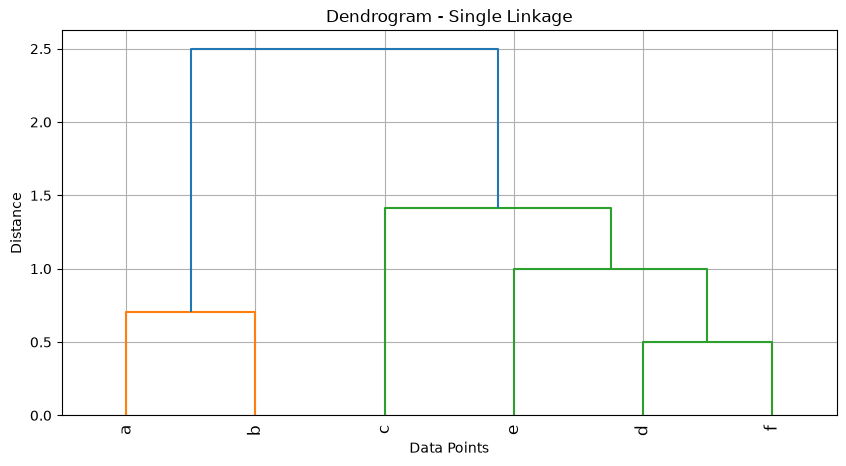

In [8]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

# Hierarchical Clustering dengan Single Linkage
linked_single = linkage(data, method='single')

# Plot Dendrogram
plt.figure(figsize=(10, 5))
plt.title("Dendrogram - Single Linkage")
dendrogram(linked_single, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

- import numpy as np sampai import matplotlib.pyplot as pltIni adalah tahap awal untuk memamnggil NumPy buat mengatur data angka, Pandas buat tabel, SciPy (linkage, dendrogram) untuk otak perhitungan hierarkinya.

- Matplotlib (plt) untuk menggambar grafiknya.
data = np.array([...]) untuk mendefinisikan data mentah berupa 6 titik koordinat (dari huruf $a$ sampai $f$). 

- linked_single = linkage(data, method='single') menjalankan algoritma hierarki menggunakan metode single linkage. algoritma akan menggabungkan dua klaster berdasarkan jarak yang paling dekat (minimum) antar titiknya.

- (plt.figure, dendrogram, plt.show) untuk hasil perhitungan linked_single menjadi diagram pohon (dendrogram). Parameter labels=['a', 'b', 'c', 'd', 'e', 'f'] menyematkan nama titik di setiap daun pohon, dan leaf_rotation=90 memutar hurufnya agar berdiri tegak. Hasil akhirnya dimunculkan ke layar menggunakan plt.show().

complete linkage 

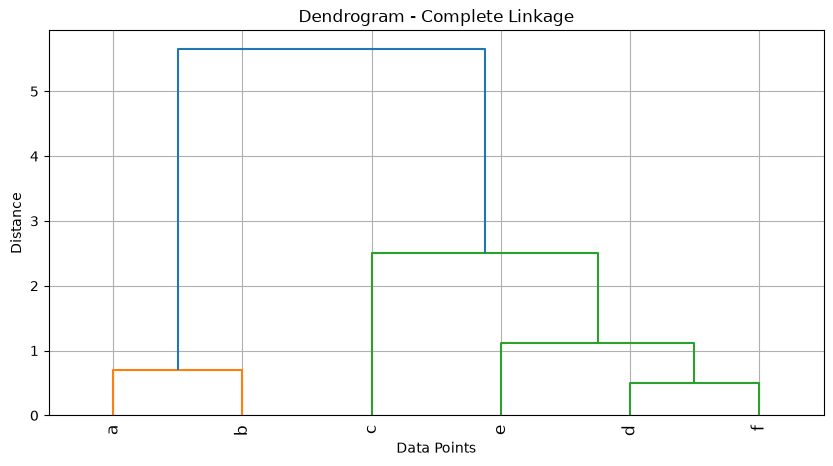

In [9]:
# Hierarchical Clustering dengan Complete Linkage
linked_complete = linkage(data, method='complete')

# Plot Dendrogram
plt.figure(figsize=(10, 5))
plt.title("Dendrogram - Complete Linkage")
dendrogram(linked_complete, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

- linked_complete = linkage(data, method='complete')
Intinya mirip dengan Sel 2, tapi parameter metodenya diganti menjadi method='complete' (pautan lengkap). Artinya, penggabungan klaster dihitung berdasarkan jarak yang paling jauh (maksimum) antara titik di klaster pertama dan klaster kedua. 

- Bagian Bawah (Plotting) kode ini menggambar diagram pohonnya ke layar, tetapi bentuk cabang dan tinggi jarak (distance) pada grafiknya akan terlihat berbeda dibandingkan hasil single linkage karena aturan jaraknya yang lebih ketat.

average linkage

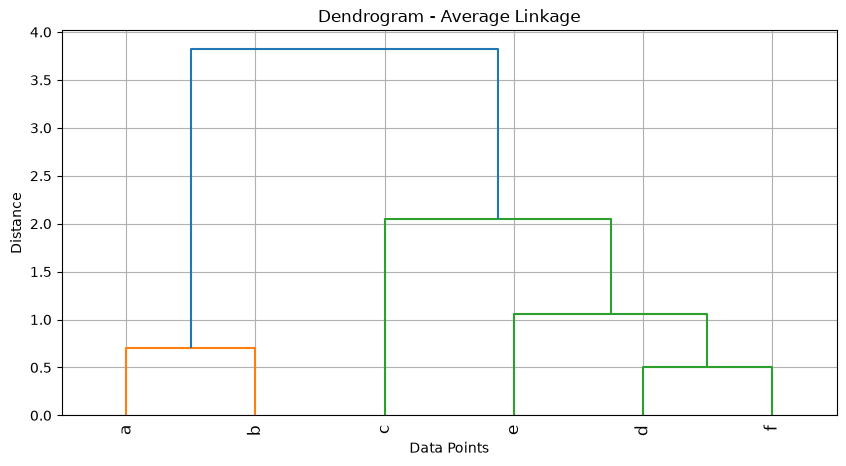

In [10]:
# Hierarchical Clustering dengan Average Linkage
linked_average = linkage(data, method='average')

# Plot Dendrogram
plt.figure(figsize=(10, 5))
plt.title("Dendrogram - Average Linkage")
dendrogram(linked_average, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

- linked_average = linkage(data, method='average') untuk menjalankan inti algoritma hierarchical clustering menggunakan metode average linkage (pautan rata-rata). Aturannya, jarak antar dua kelompok klaster dihitung berdasarkan rata-rata dari seluruh jarak pasangan titik yang ada di kedua kelompok tersebut. Hasil perhitungannya disimpan ke dalam wadah variabel linked_average.

- plt.figure(figsize=(10, 5)) untuk menyiapkan lembar kosong gambar dengan ukuran lebar 10 dan tinggi 5.

- plt.title("Dendrogram - Average Linkage") untuk memberikan judul di bagian atas grafik, yaitu "Dendrogram - Average Linkage".

- dendrogram(linked_average, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90) perintah utama untuk menggambar diagram pohon (dendrogram). Fungsi ini mengambil data dari linked_average, memasang nama huruf dari a sampai f pada setiap daun batangnya lewat parameter labels, dan memutar posisi tulisan hurufnya sebesar 90 derajat (leaf_rotation=90) agar berdiri tegak dan tidak saling bertabrakan.

- plt.xlabel("Data Points") & plt.ylabel("Distance") untuk memberi label keterangan pada sumbu bawah (X) sebagai "Data Points" dan sumbu samping (Y) sebagai "Distance" (tingkat jarak penggabungan klaster).

- plt.grid(True) untuk memunculkan garis-garis kotak bantuan (grid) di latar belakang grafik agar kita bisa membaca tingkat jarak pada sumbu Y.


ketiga metode ini menghasilkan bentuk pohon dan tinggi penggabungan klaster yang berbeda karena cara mereka mengukur jarak antar kelompok memang tidak sama. 
Pada Single Linkage, diagram cenderung menunjukkan pola penggabungan yang bertahap secara memanjang karena aturan jaraknya selalu melihat titik yang paling dekat antar kelompok, sehingga membuat beberapa titik data seolah ditarik masuk satu per satu. Sebaliknya, Complete Linkage menghasilkan bentuk diagram yang lebih ketat dan tegas, di mana kelompok-kelompok baru terbentuk pada tingkat jarak yang lebih tinggi karena metode ini mengukur jarak berdasarkan titik yang paling jauh, memaksa seluruh anggota dalam satu klaster benar-benar rapat. Sementara itu, Average Linkage sebagai penengah yang seimbang di antara keduanya,  dengan menghitung rata-rata dari seluruh pasangan titik antar klaster.